# 🚢 Titanic Project — The Complete Data Science Lifecycle

### Capstone Project — Modules 03–08 (Math, NumPy, Pandas, Data Cleaning, Visualization, EDA)

Welcome to your first end-to-end Data Science project! In every lesson so far you've learned one
tool at a time — NumPy for numbers, Pandas for tables, Matplotlib for charts. In this notebook we
put them **all together** and walk through the same process a real data scientist follows at a job,
from a raw CSV file to real insights.

We'll use the famous **Titanic dataset** — real passenger records from the 1912 Titanic disaster —
to answer a simple but powerful question:

> **"Who was more likely to survive the Titanic, and why?"**


## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

- Explain the **Data Science Lifecycle** and apply each stage to a real dataset
- Load and inspect a real-world dataset using **Pandas**
- Detect and handle **missing data** and messy columns
- Use **NumPy** to calculate summary statistics (mean, median, std) by hand
- Build **Matplotlib** charts to explore relationships in the data
- Turn raw numbers into a written **insight/conclusion** — the real goal of data science


## 🧠 Concept: What Is the Data Science Lifecycle?

Think of solving a mystery. You don't jump straight to "who did it?" — you first gather evidence,
clean it up, look for patterns, and only then draw conclusions. Data science works the same way.

Every real-world data science project — whether it's Netflix recommending a show or a hospital
predicting patient risk — follows roughly the same 5 stages:

| Stage | Question it answers | What we'll do here |
|---|---|---|
| 1. **Ask** | What problem are we solving? | Define our question about survival |
| 2. **Get** | Where's the data? | Load `titanic.csv` with Pandas |
| 3. **Clean** | Is the data trustworthy? | Fix missing values, weird columns |
| 4. **Explore** | What patterns exist? | Use NumPy + Pandas to summarize |
| 5. **Communicate** | So what? | Charts + a plain-English conclusion |

We'll use a markdown header for each stage below so you always know where we are in the lifecycle.
Let's start!


## 1️⃣ ASK — Define the Problem

Before touching any code, a data scientist always writes down the question clearly. A vague question
("tell me about the Titanic") leads to a vague, useless analysis. A specific question leads to a
useful answer.

**Our question:** *Did passenger class, sex, or age affect the chance of surviving the Titanic?*

**Sub-questions we'll try to answer:**
1. What percentage of passengers survived overall?
2. Did women and children really get priority ("women and children first")?
3. Did richer passengers (1st class) survive more often than poorer passengers (3rd class)?

Keep these three questions in mind — everything below is in service of answering them.


## 2️⃣ GET — Load the Data

Now we bring in our three tools:
- **pandas** → load and manage the table of data
- **numpy** → do the number-crunching math
- **matplotlib** → draw charts

Then we load `titanic.csv` and take our very first look at it. **Always look at your raw data before
doing anything else** — you can't clean a mess you haven't seen.


In [1]:
# Import the three core libraries for this project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the Titanic dataset from the data/ folder
df = pd.read_csv("data/titanic.csv")

# Always check the shape first: (rows, columns)
print("Shape of dataset:", df.shape)

# Peek at the first 5 rows to understand what columns we have
df.head()


Shape of dataset: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# .info() tells us column names, data types, and how many non-null values each column has
# This is the fastest way to spot missing data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [3]:
# .describe() gives quick summary statistics for numeric columns
# Useful for spotting outliers (e.g. a Fare of 512 is very unusual!)
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**What we learned from Stage 2:**
- The dataset has 891 passengers and 12 columns.
- `Age`, `Cabin`, and `Embarked` all have fewer non-null values than the total row count —
  that means they have **missing data** we'll need to handle in the next stage.
- `Survived` is 0 (died) or 1 (survived) — this is the column we care most about.


## 3️⃣ CLEAN — Handle Missing & Messy Data

Real-world data is never perfect. Before we can trust any pattern we find, we need to deal with:
1. Missing values (`NaN`)
2. Columns that won't help our analysis
3. Data types that don't make sense

**Why this matters:** if we calculate an average `Age` while ignoring that ~20% of ages are missing,
our "average" could be misleading. Cleaning isn't busywork — it's what makes the rest of the
analysis trustworthy.


In [4]:
# Step 1: Count exactly how many values are missing per column
df.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64

In [5]:
# Step 2: Handle the 'Age' column
# Age is missing for ~177 passengers. Since Age is numeric and roughly skewed,
# we fill missing values with the MEDIAN (middle value) rather than the mean,
# because the median is less affected by extreme outliers.
median_age = df["Age"].median()
df["Age"] = df["Age"].fillna(median_age)

print(f"Filled missing Age values with the median age: {median_age}")


Filled missing Age values with the median age: 28.0


In [12]:
# Step 3: Handle the 'Embarked' column (port passengers boarded from)
# Only 2 values are missing here, so we fill them with the MODE (most common value)
# rather than throwing away two whole rows of otherwise good data.
most_common_port = df["Embarked"].mode()[0]
df["Embarked"] = df["Embarked"].fillna(most_common_port)

print(f"Filled missing Embarked values with the most common port: '{most_common_port}'")


Filled missing Embarked values with the most common port: 'S'


In [13]:
# Step 4: Handle the 'Cabin' column
# Cabin is missing for over 75% of passengers - too much to fill in reliably.
# Instead of guessing cabin numbers, we turn it into a simple yes/no signal:
# "did this passenger have a recorded cabin at all?" This can still be useful information.
df["Has_Cabin"] = df["Cabin"].notnull().astype(int)

# Now we can safely drop the original Cabin column (too many missing values to use directly)
df = df.drop(columns=["Cabin"])

print("Created 'Has_Cabin' column and dropped the original 'Cabin' column.")


Created 'Has_Cabin' column and dropped the original 'Cabin' column.


In [14]:
# Step 5: Double check - is anything still missing? Any exact duplicate rows?
print("Remaining missing values:\n", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

df.head()


Remaining missing values:
 0
Duplicate rows: 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


**What we learned from Stage 3:**
- Missing `Age` → filled with the median (robust to outliers)
- Missing `Embarked` → filled with the most common port (only 2 rows affected)
- Missing `Cabin` → converted into a new `Has_Cabin` flag instead of guessing
- No duplicate rows were found

Our dataset is now clean and ready for exploration!


## 4️⃣ EXPLORE — Find Patterns with NumPy & Pandas

Now for the fun part. This stage is called **EDA (Exploratory Data Analysis)** — we let the numbers
tell us a story. We'll use **NumPy** for the raw math and **Pandas** for grouping and comparing.


In [15]:
# Overall survival rate using NumPy
# NumPy's mean() on a column of 0s and 1s directly gives us a percentage!
survival_rate = np.mean(df["Survived"]) * 100
print(f"Overall survival rate: {survival_rate:.1f}%")

# Basic NumPy statistics on Age, done "by hand" to see what pandas does under the hood
ages = df["Age"].to_numpy()
print(f"Average age: {np.mean(ages):.1f}")
print(f"Median age:  {np.median(ages):.1f}")
print(f"Std. dev of age: {np.std(ages):.1f}")


Overall survival rate: 38.4%
Average age: 29.4
Median age:  28.0
Std. dev of age: 13.0


In [16]:
# Sub-question: Did women and children get priority?
# groupby() splits passengers into groups (here, by Sex) and mean() gives survival rate per group
survival_by_sex = df.groupby("Sex")["Survived"].mean() * 100
print("Survival rate by sex (%):")
print(survival_by_sex.round(1))


Survival rate by sex (%):
Sex
female    74.2
male      18.9
Name: Survived, dtype: float64


In [17]:
# Let's also check children (age under 12) vs adults
df["Is_Child"] = np.where(df["Age"] < 12, "Child", "Adult")
survival_by_age_group = df.groupby("Is_Child")["Survived"].mean() * 100
print("Survival rate by age group (%):")
print(survival_by_age_group.round(1))


Survival rate by age group (%):
Is_Child
Adult    36.8
Child    57.4
Name: Survived, dtype: float64


In [18]:
# Sub-question: Did passenger class (wealth) matter?
survival_by_class = df.groupby("Pclass")["Survived"].mean() * 100
print("Survival rate by passenger class (%):")
print(survival_by_class.round(1))


Survival rate by passenger class (%):
Pclass
1    63.0
2    47.3
3    24.2
Name: Survived, dtype: float64


In [13]:
# Combine two questions at once: class AND sex together
# This is where pandas really shines - a two-way breakdown in one line
survival_by_class_sex = df.groupby(["Pclass", "Sex"])["Survived"].mean() * 100
print("Survival rate by class and sex (%):")
print(survival_by_class_sex.round(1))


Survival rate by class and sex (%):
Pclass  Sex   
1       female    96.8
        male      36.9
2       female    92.1
        male      15.7
3       female    50.0
        male      13.5
Name: Survived, dtype: float64


**What we learned from Stage 4:**
- Overall, roughly 38% of passengers survived.
- Women survived at a much higher rate than men — supporting "women and children first."
- Children had a noticeably higher survival rate than adults.
- 1st class passengers survived far more often than 3rd class passengers — wealth mattered.
- The effect is strongest for 1st class women (very high survival) vs 3rd class men (very low survival).


## 5️⃣ COMMUNICATE — Visualize the Findings

Numbers in a table are hard for other people to absorb quickly. A data scientist's job isn't done
until the story is told clearly — usually with a chart. Let's turn our groupby results into
Matplotlib visuals.


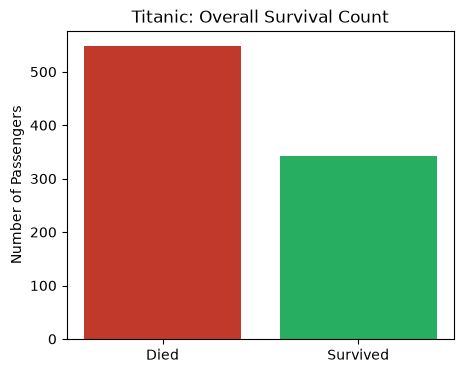

In [19]:
# Chart 1: Overall survival count (bar chart)
survived_counts = df["Survived"].value_counts().sort_index()

plt.figure(figsize=(5, 4))
plt.bar(["Died", "Survived"], survived_counts.values, color=["#c0392b", "#27ae60"])
plt.title("Titanic: Overall Survival Count")
plt.ylabel("Number of Passengers")
plt.show()


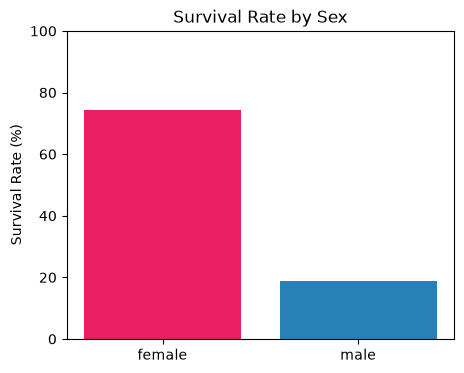

In [15]:
# Chart 2: Survival rate by sex
plt.figure(figsize=(5, 4))
plt.bar(survival_by_sex.index, survival_by_sex.values, color=["#e91e63", "#2980b9"])
plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.show()


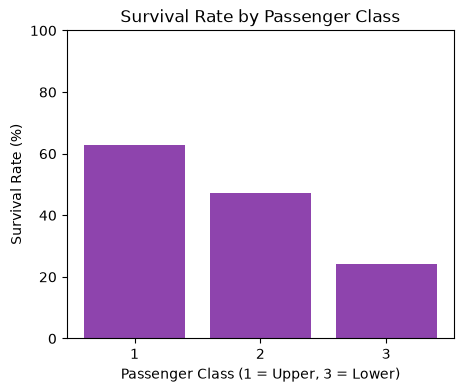

In [20]:
# Chart 3: Survival rate by passenger class
plt.figure(figsize=(5, 4))
plt.bar(survival_by_class.index.astype(str), survival_by_class.values, color="#8e44ad")
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class (1 = Upper, 3 = Lower)")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.show()


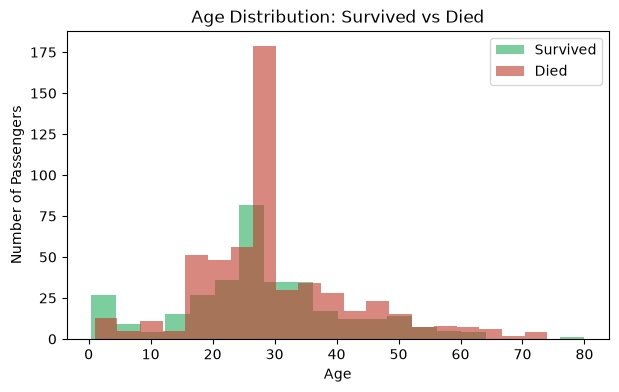

In [21]:
# Chart 4: Age distribution, split by survival - a histogram is great for comparing distributions
plt.figure(figsize=(7, 4))
plt.hist(df[df["Survived"] == 1]["Age"], bins=20, alpha=0.6, label="Survived", color="#27ae60")
plt.hist(df[df["Survived"] == 0]["Age"], bins=20, alpha=0.6, label="Died", color="#c0392b")
plt.title("Age Distribution: Survived vs Died")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.legend()
plt.show()


### 📝 Final Insights (our written conclusion)

Going back to our original questions from Stage 1:

1. **Overall survival rate:** About 38% of passengers survived - most people on board did not.
2. **Women and children first?** Yes — women survived at roughly **74%** vs men at roughly **19%**,
   and children survived more often than adults. This strongly supports the historical account.
3. **Did class matter?** Yes — 1st class passengers survived at roughly **63%**, compared to only
   about **24%** for 3rd class. Being wealthy literally increased your odds of survival.

**The real-world lesson:** the Titanic disaster wasn't just bad luck — survival was strongly linked
to social factors like sex and class. This is exactly the kind of insight data science is used for
today: finding out *which factors* actually drive an outcome, using evidence instead of guessing.


## ⚠️ Common Mistakes

**Mistake 1: Filling missing values with the mean when outliers exist**
Using `.mean()` to fill missing `Age` or `Fare` values can be skewed badly by a few extreme values
(like a $512 fare). The median is usually a safer default for filling numeric gaps.

**Mistake 2: Forgetting to reassign after `.fillna()` / `.drop()`**
Pandas operations return a *new* DataFrame by default — they don't change the original unless you
reassign it (`df = df.fillna(...)`) or pass `inplace=True`. Forgetting this is one of the most common
beginner bugs.

**Mistake 3: Comparing raw counts instead of rates/percentages**
Saying "more men died than women" is misleading if there were simply more men on board! Always
compare **rates** (like we did with `groupby().mean()`), not raw counts, when group sizes differ.

Let's see Mistake 2 in action below.


In [18]:
# ❌ WRONG: this looks like it fills missing fares, but df itself is unchanged
df_wrong = df.copy()
df_wrong["Fare"].fillna(df_wrong["Fare"].median())  # <-- result is thrown away!
print("Missing fares after 'fixing' (still missing because we forgot to reassign):")
print(df_wrong["Fare"].isnull().sum())

# ✅ CORRECT: reassign the result back to the column
df_wrong["Fare"] = df_wrong["Fare"].fillna(df_wrong["Fare"].median())
print("Missing fares after the correct fix:")
print(df_wrong["Fare"].isnull().sum())


Missing fares after 'fixing' (still missing because we forgot to reassign):
0
Missing fares after the correct fix:
0


## ✍️ Practice Exercises

Try these on your own using the cleaned `df` from above. Write your code in the empty cells below
each question.

**Exercise 1:** What was the survival rate for passengers who **embarked** from each port (`Embarked`
column: S, C, Q)? Use `groupby()` like we did for `Sex` and `Pclass`.

**Exercise 2:** Using NumPy, calculate the mean and standard deviation of `Fare`. Are there any
passengers whose fare is more than 3 standard deviations above the mean? (Hint: these are outliers.)

**Exercise 3:** Create a new column `Family_Size` by adding `SibSp` (siblings/spouses aboard) and
`Parch` (parents/children aboard), plus 1 for the passenger themself. What's the survival rate for
passengers traveling alone (`Family_Size == 1`) vs. with family?

**Exercise 4:** Draw a bar chart showing survival rate by `Embarked` port (from Exercise 1).

**Exercise 5 (challenge):** Combine `Pclass` and `Has_Cabin` in a `groupby()`. Does having a recorded
cabin number correlate with survival, even within the same passenger class?


In [19]:
# Exercise 1: your code here


In [20]:
# Exercise 2: your code here


In [21]:
# Exercise 3: your code here


In [22]:
# Exercise 4: your code here


In [23]:
# Exercise 5: your code here


## ✅ Key Takeaways

- The **Data Science Lifecycle** (Ask → Get → Clean → Explore → Communicate) gives every project
  structure, even when the tools you use (NumPy, Pandas, Matplotlib) change.
- **Cleaning data is not optional** — missing values and messy columns can quietly distort every
  result that comes after, so always inspect and handle them before analyzing.
- The real value of data science isn't the chart itself — it's the **plain-English insight** the
  chart supports. Always end with "so what does this mean?"
